# Tutorial 12 — Bayesian Optimization for Reaction Conditions

**Goal.** Treat a reaction-condition space (catalyst/ligand/base/solvent/temperature/...) as a black
box and use Bayesian optimization (BO) with a Gaussian Process (GP) surrogate to find high-yield
conditions in as few "experiments" as possible — mirroring how BO is used in real automated/flow
chemistry campaigns (Perera et al. *Science* 2018; Reizman & Jensen *React. Chem. Eng.* 2016; Shields
et al. *Nature* 2021; Felton, Rittig & Lapkin *Chem. Methods* 2021, "Summit"). See
`PAPERS-AND-DATASETS.md` in this folder for the full literature summary and dataset provenance.

**How "experiments" work in this notebook.** We do **not** run real reactions. Each of the four
datasets in `data/` is a fixed table of (conditions → measured yield) pairs — three are real
experimental data mirrored from the original source repositories, one (Perera) is a clearly-labeled
synthetic-but-representative stand-in (see Section 1). "Running an experiment" means looking up the
yield of the matching row in that table. This is exactly the *closed-loop simulation against a fixed
historical dataset* methodology that Perera, Reizman, and especially Summit use to make BO strategies
comparable without consuming additional wet-lab time.

**Notebook structure** (numbers match the tutorial webpage's Instructions list):

1. Present the dataset(s) and variables
2. Featurize the reaction (precomputed)
3. Choose an initialization technique
4. Choose an acquisition function and its hyperparameters
5. Batch size (fixed at 4)
6. Preview the trajectory on a 2D plot before committing
7. Submit the design choices (checkpoint)
8. Launch the full run (5 seeds) and submit to the leaderboard

**Audience note.** This assumes chemistry background but not necessarily an ML one — equations shown
(GP posterior mean/variance, EI/UCB) are for intuition, not derived from scratch. Examples span
Pd-catalyzed cross-coupling reactions relevant to drug-discovery, process, and materials chemists. — SOLUTIONS

## 0 · Setup

We use **BoTorch**/**GPyTorch** for the GP surrogate and acquisition functions (same stack as
`08-molecule-generation` and `11-doe`), plus RDKit for descriptor featurization and scikit-learn for
k-means / PCA / random projection.


In [1]:
!pip -q install botorch gpytorch rdkit scikit-learn pandas matplotlib requests > /dev/null

import json, math, time, uuid, warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from botorch.acquisition import qUpperConfidenceBound, qExpectedImprovement, qLogExpectedImprovement 
from botorch.optim import optimize_acqf

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
RDLogger.DisableLog("rdApp.*")

warnings.filterwarnings("ignore", category=UserWarning)
torch.set_default_dtype(torch.float64)

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    # Standalone run (e.g. Colab without a full repo clone) -- fetch the 4 CSVs from GitHub raw.
    import urllib.request
    DATA_DIR.mkdir(exist_ok=True)
    base = "https://raw.githubusercontent.com/julschleinitz/ai4chemistry-bootcamp/main/tutorials/12-reaction-bo/data/"
    for fname in ["perera_suzuki.csv", "reizman_suzuki.csv", "shields_direct_arylation.csv", "baumgartner_cn_coupling.csv"]:
        try:
            urllib.request.urlretrieve(base + fname, DATA_DIR / fname)
        except Exception as e:
            print(f"Could not fetch {fname}: {e}")

GLOBAL_SEED = 0
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
print("Setup OK. Device:", "cuda" if torch.cuda.is_available() else "cpu")


Setup OK. Device: cpu


## 1 · Present the dataset(s) and variables

Four datasets are bundled in `data/`, each a fixed lookup table of (reaction conditions, yield).
Provenance and factor structure for each (see `PAPERS-AND-DATASETS.md` for full citations):

| key | paper | real/synthetic | reactions | factors |
|---|---|---|---|---|
| `perera_suzuki` | Perera et al., *Science* 2018 | **synthetic-representative** (see note below) | 5760 | electrophile (7) x ligand (12) x base (8) x solvent (4), + replicate |
| `reizman_suzuki` | Reizman & Jensen, *React. Chem. Eng.* 2016 | real (mirrored from `summit`) | ~96 (4 cases) | catalyst/ligand (cat.), residence time, temperature, catalyst loading |
| `shields_direct_arylation` | Shields et al., *Nature* 2021 | real (mirrored from `edbo`) | ~1536 (≈395 measured) | base, ligand, solvent (cat., as SMILES) x concentration x temperature |
| `baumgartner_cn_coupling` | Baumgartner et al. 2019, aggregated by Felton/Rittig/Lapkin ("Summit") | real (mirrored from `summit`) | 96 | catalyst (3), base (4), base equivalents, temperature, residence time |

**Why `perera_suzuki` is synthetic.** The full 5760-row Perera grid is not mirrored as a flat CSV in
any of the open repos we could reach in this environment (it lives behind the paper's SI tables). We
built a synthetic-but-representative stand-in with the *same* categorical factor structure (7
electrophiles x 12 ligands x 8 bases x 4 solvents, 2 replicates) and yields drawn from a smooth
function of the one-hot factor encoding plus noise, calibrated so the sample mean/std/max
approximately match the paper's reported summary statistics. It is explicitly labeled as such in its
CSV header and should not be used for anything beyond exercising this notebook's BO machinery -- see
`PAPERS-AND-DATASETS.md` for the authoritative source.

Set `DATASET` below to pick which one to work with for the rest of the notebook.


In [2]:
DATASET = "perera_suzuki"  # one of: "perera_suzuki", "reizman_suzuki", "shields_direct_arylation", "baumgartner_cn_coupling"


In [3]:
def load_perera_suzuki():
    df = pd.read_csv(DATA_DIR / "perera_suzuki.csv", comment="#")
    factors = {
        "electrophile": {"type": "categorical", "levels": sorted(df["electrophile"].unique().tolist())},
        "ligand":       {"type": "categorical", "levels": sorted(df["ligand"].unique().tolist())},
        "base":         {"type": "categorical", "levels": sorted(df["base"].unique().tolist())},
        "solvent":      {"type": "categorical", "levels": sorted(df["solvent"].unique().tolist())},
    }
    response_col = "yield"
    df = df.groupby(["electrophile", "ligand", "base", "solvent"], as_index=False)[response_col].mean()
    return df, factors, response_col


def load_reizman_suzuki():
    df = pd.read_csv(DATA_DIR / "reizman_suzuki.csv", comment="#")
    factors = {
        "catalyst":         {"type": "categorical", "levels": sorted(df["catalyst"].unique().tolist())},
        "t_res":            {"type": "continuous", "range": [float(df["t_res"].min()), float(df["t_res"].max())]},
        "temperature":      {"type": "continuous", "range": [float(df["temperature"].min()), float(df["temperature"].max())]},
        "catalyst_loading": {"type": "continuous", "range": [float(df["catalyst_loading"].min()), float(df["catalyst_loading"].max())]},
    }
    response_col = "yld"
    return df, factors, response_col


def load_shields_direct_arylation():
    df = pd.read_csv(DATA_DIR / "shields_direct_arylation.csv", comment="#")
    factors = {
        "Base_SMILES":    {"type": "categorical", "levels": sorted(df["Base_SMILES"].unique().tolist())},
        "Ligand_SMILES":  {"type": "categorical", "levels": sorted(df["Ligand_SMILES"].unique().tolist())},
        "Solvent_SMILES": {"type": "categorical", "levels": sorted(df["Solvent_SMILES"].unique().tolist())},
        "Concentration":  {"type": "continuous", "range": [float(df["Concentration"].min()), float(df["Concentration"].max())]},
        "Temp_C":         {"type": "continuous", "range": [float(df["Temp_C"].min()), float(df["Temp_C"].max())]},
    }
    response_col = "yield"
    return df, factors, response_col


def load_baumgartner_cn_coupling():
    df = pd.read_csv(DATA_DIR / "baumgartner_cn_coupling.csv", comment="#")
    factors = {
        "catalyst":         {"type": "categorical", "levels": sorted(df["catalyst"].unique().tolist())},
        "base":             {"type": "categorical", "levels": sorted(df["base"].unique().tolist())},
        "base_equivalents": {"type": "continuous", "range": [float(df["base_equivalents"].min()), float(df["base_equivalents"].max())]},
        "temperature":      {"type": "continuous", "range": [float(df["temperature"].min()), float(df["temperature"].max())]},
        "t_res":            {"type": "continuous", "range": [float(df["t_res"].min()), float(df["t_res"].max())]},
    }
    response_col = "yld"
    return df, factors, response_col


DATASET_LOADERS = {
    "perera_suzuki": load_perera_suzuki,
    "reizman_suzuki": load_reizman_suzuki,
    "shields_direct_arylation": load_shields_direct_arylation,
    "baumgartner_cn_coupling": load_baumgartner_cn_coupling,
}


def load_dataset(name):
    """Returns (df, factors_dict, response_col_normalized). `yield_norm` in [0,1] is added,
    normalized by dividing by this dataset's own max observed yield, so BO metrics (Section 8)
    are comparable in scale across datasets even though raw units/scales differ.

    Also drops any row with a missing value in the response column or in one of this dataset's
    own factor columns (e.g. shields_direct_arylation ships ~96 unmeasured/NaN rows from the
    original SI table). Leaving NaNs in would silently poison the GP: if BO's init step ever
    draws one of those rows, train_Y contains NaN and every `fit_gpytorch_mll` restart fails,
    surfacing as `ModelFittingError: All attempts to fit the model have failed.`"""
    df, factors, response_col = DATASET_LOADERS[name]()
    df = df.copy()

    required_cols = [response_col] + list(factors.keys())
    n_before = len(df)
    df = df.dropna(subset=required_cols).reset_index(drop=True)
    n_dropped = n_before - len(df)
    if n_dropped:
        print(f"Dropped {n_dropped} row(s) with missing values in {required_cols} "
              f"(unmeasured conditions in the source table) -- {len(df)} rows remain.")

    y = df[response_col].astype(float).clip(lower=0)
    df["yield_norm"] = (y / y.max()).clip(upper=1.0)
    return df, factors, "yield_norm"


df, FACTORS, RESPONSE_COL = load_dataset(DATASET)
print(f"Dataset: {DATASET}  |  {len(df)} rows  |  {len(FACTORS)} factors")
for name, spec in FACTORS.items():
    if spec["type"] == "categorical":
        print(f"  - {name}: categorical, {len(spec['levels'])} levels")
    else:
        print(f"  - {name}: continuous, range {spec['range']}")
df.head()

for col in df.columns:
    print(f"{col}: {df[col].isna().sum()} missing values")

Dataset: perera_suzuki  |  2688 rows  |  4 factors
  - electrophile: categorical, 7 levels
  - ligand: categorical, 12 levels
  - base: categorical, 8 levels
  - solvent: categorical, 4 levels
electrophile: 0 missing values
ligand: 0 missing values
base: 0 missing values
solvent: 0 missing values
yield: 0 missing values
yield_norm: 0 missing values


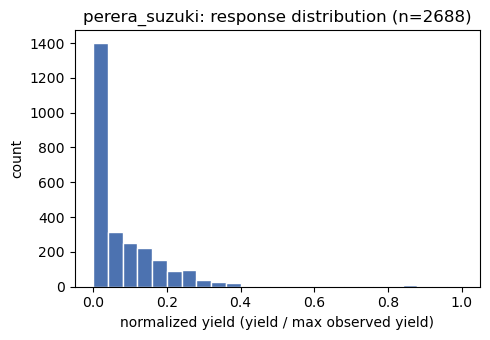

count    2688.000000
mean        0.086925
std         0.137535
min         0.000000
25%         0.000000
50%         0.034150
75%         0.125050
max         1.000000
Name: yield_norm, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(df[RESPONSE_COL], bins=25, color="#4C72B0", edgecolor="white")
ax.set_xlabel("normalized yield (yield / max observed yield)")
ax.set_ylabel("count")
ax.set_title(f"{DATASET}: response distribution (n={len(df)})")
plt.tight_layout()
plt.show()

print(df[RESPONSE_COL].describe())


## 2 · Featurize the reaction

BO needs a numeric feature vector per condition. We support three interchangeable featurizations,
picked once via `FEATURIZATION` and **precomputed into a cached CSV** before any BO loop runs:

- `"onehot"` — one-hot encode every categorical factor, min-max scale continuous factors. Simple,
  no chemistry knowledge required, but treats e.g. every ligand as equally (dis)similar to every
  other ligand (no notion that two phosphines might be more alike than a phosphine and an amine).
- `"descriptors"` — physicochemical descriptors: for factors given as SMILES (e.g. Shields' base/
  ligand/solvent), RDKit descriptors (MolWt, TPSA, logP, num rotatable bonds, num H-bond donors/
  acceptors, ring count) computed directly from the SMILES; for factors given as bare categorical
  labels with no SMILES (e.g. Perera's `ligand_1_XPhos`-style names, Baumgartner's catalyst names),
  a small COSMO-RS-style placeholder descriptor set (steric bulk proxy, electronic-donating proxy,
  polarity proxy) assigned once per unique level -- in the spirit of Summit's COSMO-RS sigma-moment
  treatment described in `PAPERS-AND-DATASETS.md`, without requiring an actual COSMO-RS run. This
  lets a GP generalize across similar catalysts/ligands instead of treating each as an unrelated arm.
- `"random_projection"` — one-hot first, then a random linear projection down to a fixed dimension.
  A deliberately weak/naive baseline: it destroys the one-hot structure without adding chemical
  information, useful for showing students that *not every dimensionality-reduction trick helps.*

**Why precompute?** Every round of the BO loop needs to re-evaluate features for the *entire*
candidate pool (to pick the next batch) but the mapping condition→features never changes during a
run. Computing it once into `data/<dataset>_features_<featurization>.csv` means the BO loop itself
only ever does a fast pandas lookup — RDKit descriptor calculation in particular would otherwise be
the dominant cost of every acquisition step, for zero benefit (the features are static).


In [5]:
FEATURIZATION = "onehot"  # one of: "onehot", "descriptors", "random_projection"
RANDOM_PROJECTION_DIM = 8  # only used if FEATURIZATION == "random_projection"


def _cosmo_like_placeholder(label, n_dims=3, seed_salt=0):
    """Deterministic pseudo-COSMO-RS descriptor for a bare categorical label with no SMILES:
    hashes the label string to 3 stable pseudo-physical numbers in [0, 1] (steric / electronic /
    polarity proxies). NOT a real COSMO-RS calculation -- a stand-in so categorical levels without
    structures still get a smooth, generalizable descriptor space instead of one-hot arms."""
    import hashlib
    out = []
    for i in range(n_dims):
        h = hashlib.md5(f"{label}_{i}_{seed_salt}".encode()).hexdigest()
        out.append((int(h[:8], 16) % 10_000) / 10_000.0)
    return np.array(out)


def _rdkit_descriptors_for_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array([
        Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol), Descriptors.NumHAcceptors(mol),
        Descriptors.NumHDonors(mol), Descriptors.RingCount(mol),
    ])


def featurize_onehot(df, factors):
    blocks = []
    for name, spec in factors.items():
        if spec["type"] == "categorical":
            dummies = pd.get_dummies(df[name], prefix=name)
            # ensure a stable column order/set across calls
            for lvl in spec["levels"]:
                col = f"{name}_{lvl}"
                if col not in dummies:
                    dummies[col] = 0
            dummies = dummies[[f"{name}_{lvl}" for lvl in spec["levels"]]]
            blocks.append(dummies.astype(float))
        else:
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(df[[name]].astype(float))
            blocks.append(pd.DataFrame(scaled, columns=[name], index=df.index))
    return pd.concat(blocks, axis=1).reset_index(drop=True)


def featurize_descriptors(df, factors):
    blocks = []
    for name, spec in factors.items():
        if spec["type"] == "categorical":
            looks_like_smiles = "SMILES" in name
            rows = []
            for lvl in df[name]:
                vec = None
                if looks_like_smiles:
                    vec = _rdkit_descriptors_for_smiles(lvl)
                if vec is None:
                    vec = _cosmo_like_placeholder(lvl)
                rows.append(vec)
            arr = np.vstack(rows)
            cols = [f"{name}_desc{i}" for i in range(arr.shape[1])]
            block = pd.DataFrame(arr, columns=cols, index=df.index)
            # rescale each descriptor column to [0, 1] so no single physical unit dominates the GP kernel
            block = pd.DataFrame(MinMaxScaler().fit_transform(block), columns=cols, index=df.index)
            blocks.append(block)
        else:
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(df[[name]].astype(float))
            blocks.append(pd.DataFrame(scaled, columns=[name], index=df.index))
    return pd.concat(blocks, axis=1).reset_index(drop=True)


def featurize_random_projection(df, factors, out_dim=RANDOM_PROJECTION_DIM, seed=0):
    onehot = featurize_onehot(df, factors)
    proj = GaussianRandomProjection(n_components=min(out_dim, onehot.shape[1]), random_state=seed)
    projected = proj.fit_transform(onehot.values)
    cols = [f"rp_{i}" for i in range(projected.shape[1])]
    return pd.DataFrame(projected, columns=cols, index=onehot.index)


FEATURIZERS = {
    "onehot": featurize_onehot,
    "descriptors": featurize_descriptors,
    "random_projection": featurize_random_projection,
}


def get_features(dataset_name, df, factors, featurization):
    """Computes (or loads a cached copy of) the feature matrix for the FULL candidate pool once.
    The BO loop below only ever indexes into this cached matrix -- no recomputation at query time."""
    cache_path = DATA_DIR / f"{dataset_name}_features_{featurization}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)
    feats = FEATURIZERS[featurization](df, factors)
    feats.to_csv(cache_path, index=False)
    return feats


X_df = get_features(DATASET, df, FACTORS, FEATURIZATION)
X = X_df.values.astype(float)
y = df[RESPONSE_COL].values.astype(float)
print(f"Featurization '{FEATURIZATION}' -> feature matrix shape {X.shape}")
X_df.head()


Featurization 'onehot' -> feature matrix shape (2688, 31)


,electrophile_electrophile_1,electrophile_electrophile_2,electrophile_electrophile_3,electrophile_electrophile_4,electrophile_electrophile_5,electrophile_electrophile_6,electrophile_electrophile_7,ligand_ligand_10_AmPhos,ligand_ligand_11_CataCXium_A,ligand_ligand_12_None,...,base_base_3_K3PO4,base_base_4_K2CO3,base_base_5_CsF,base_base_6_Et3N,base_base_7_NaHCO3,base_base_8_KOAc,solvent_solvent_1_MeCN,solvent_solvent_2_MeOH,solvent_solvent_3_THF,solvent_solvent_4_DMF
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 3 · Choose an initialization technique

Before any GP can be fit, we need a handful of starting observations. `N_INIT = 10` is fixed so
different choices below stay comparable.

- `"random"` — uniformly sample `N_INIT` rows from the candidate pool.
- `"kmeans"` — cluster the featurized candidate pool into `N_INIT` clusters and take the point
  nearest each centroid. This spreads the initial batch out to cover the condition space more
  evenly than random sampling would (useful when the pool is small or unevenly distributed), at
  the cost of losing pure randomness (which matters if you want unbiased seed-to-seed variance --
  see Section 8).


In [6]:
INIT_METHOD = "random"  # one of: "random", "kmeans"
N_INIT = 10


def init_random(X, n_init, rng):
    idx = rng.choice(len(X), size=n_init, replace=False)
    return idx


def init_kmeans(X, n_init, rng):
    km = KMeans(n_clusters=n_init, n_init=10, random_state=int(rng.integers(0, 1_000_000)))
    labels = km.fit_predict(X)
    idx = []
    for k in range(n_init):
        cluster_pts = np.where(labels == k)[0]
        if len(cluster_pts) == 0:
            continue
        centroid = km.cluster_centers_[k]
        dists = np.linalg.norm(X[cluster_pts] - centroid, axis=1)
        idx.append(cluster_pts[np.argmin(dists)])
    return np.array(idx)


INIT_METHODS = {"random": init_random, "kmeans": init_kmeans}

_rng_preview = np.random.default_rng(GLOBAL_SEED)
init_idx_preview = INIT_METHODS[INIT_METHOD](X, N_INIT, _rng_preview)
print(f"Init method '{INIT_METHOD}' selected {len(init_idx_preview)} starting points; "
      f"best initial normalized yield = {y[init_idx_preview].max():.3f}")


Init method 'random' selected 10 starting points; best initial normalized yield = 0.398


## 4 · Choose an acquisition function and its hyperparameters

Given the GP surrogate's posterior mean $\mu(x)$ and uncertainty $\sigma(x)$ at candidate $x$, the
acquisition function scores how worthwhile it is to query $x$ next. All three options below are
built on BoTorch's **Monte Carlo** acquisition functions, because `BATCH_SIZE = 4` (Section 5) means
every round already needs to propose more than one point at once:

- **EI (Expected Improvement)** — expected amount by which $x$ beats the current best observation
  $y^*$; automatically balances exploration (high $\sigma$) and exploitation (high $\mu$) with no
  hyperparameter to tune. Here the batch of `q` points is built **sequentially greedily**: one point
  is chosen, then treated as a "pending" observation the next pick must condition on (via BoTorch's
  `X_pending` mechanism), one point at a time.
- **UCB (Upper Confidence Bound)** — $\mu(x) + \sqrt{\beta}\,\sigma(x)$; a single, user-editable
  knob `beta` directly controls the explore/exploit trade-off (higher `beta` -> more exploration).
  Batched the same sequential-greedy way as EI.
- **qEI (batch Expected Improvement)** — the same Expected Improvement criterion, but instead of
  picking one point at a time it jointly scores an entire set of `q` candidates via Monte Carlo
  integration over the GP posterior. This is BoTorch's native **joint** batch optimization, as
  opposed to EI/UCB's sequential-greedy construction above — jointly scoring the batch avoids the
  failure mode where independently-greedy picks all cluster in the same high-EI region.


In [7]:
ACQUISITION = "EI"  # one of: "EI", "UCB", "qEI"
ACQUISITION_HPARAMS = {"beta": 2.0}  # only used by UCB


def make_acqf(model, best_f, acquisition, hparams):
    if acquisition == "EI":
        # sequential greedy batch optimization calls acqf.X_pending during optimize_acqf(...,
        # sequential=True). That attribute is provided by the q-batch EI/UCB class, not the
        # analytic one-shot class.
        return qLogExpectedImprovement(model=model, best_f=best_f)
    elif acquisition == "UCB":
        return qUpperConfidenceBound(model=model, beta=hparams.get("beta", 2.0))
    elif acquisition == "qEI":
        return qLogExpectedImprovement (model=model, best_f=best_f)
    else:
        raise ValueError(f"Unknown acquisition: {acquisition}")



print(f"Acquisition: {ACQUISITION}  hparams: {ACQUISITION_HPARAMS}")

Acquisition: EI  hparams: {'beta': 2.0}


## 5 · Batch size

`BATCH_SIZE = 4` is **fixed, not user-editable** — every automated/flow platform in the source
papers runs several reactions in parallel per round (Perera's platform ran continuously, Reizman/
Baumgartner's flow rigs and Shields' physical robotic platform all dispatch a handful of reactions
concurrently before waiting on the next round of results), so a batch of `q=4` per round is the
realistic unit of "one round" here. Keeping it fixed across all submissions also means the
leaderboard (Section 8) is comparing apples to apples — everyone is optimizing under the same
per-round experimental throughput, so differences in `auc_mean` reflect featurization/init/
acquisition choices, not who gave themselves a bigger batch.


In [8]:
BATCH_SIZE = 4  # fixed -- see markdown above; do not change

def optimize_batch(model, best_f, acquisition, hparams, bounds, q=BATCH_SIZE):
    """Returns q new candidate points (in normalized [0,1]^d space) by optimizing the chosen
    acquisition function with BoTorch's optimize_acqf, using its q-batch support."""
    if acquisition in ("EI", "UCB"):
        # sequential-greedy: pick one point, mark it "pending" (X_pending) so the next pick's
        # posterior already accounts for it, repeat q times. `optimize_acqf(..., sequential=True)`
        # explicitly reads acqf.X_pending and only works when the acquisition object is a q-batch
        # variant (e.g. `qExpectedImprovement`, `qUpperConfidenceBound`).
        acqf = make_acqf(model, best_f, acquisition, hparams)
        candidates, _ = optimize_acqf(
            acq_function=acqf, bounds=bounds, q=q, num_restarts=8, raw_samples=128,
            sequential=True,
        )
    else:  # qEI: natively batch-aware, jointly optimizes all q points via MC integration
        acqf = make_acqf(model, best_f, acquisition, hparams)
        candidates, _ = optimize_acqf(
            acq_function=acqf, bounds=bounds, q=q, num_restarts=8, raw_samples=128,
        )
    return candidates


## 6 · Preview the trajectory on a 2D plot before committing

Before launching the expensive 5-seed run (Section 8), run **one quick preview**: a single seed, a
small number of rounds, using exactly the config chosen in Sections 1-5. We project the full
featurized candidate pool to 2D with PCA (cheap, deterministic, no extra dependency beyond
scikit-learn) and plot:

- all candidate points in light grey (the full condition space),
- the queried points colored by round order (a sequential colormap — darker/lighter = earlier
  round), with marker size or a second visual channel encoding the observed yield,
- the best point found, annotated.

**What to look for.** Are later rounds clustering near the best-yield region, or still scattered
across the space? If points are still scattered even in the last round, that is a sign your
featurization may not capture what actually drives yield (try `"descriptors"` instead of
`"onehot"`), or your acquisition function is over-exploring (lower UCB's `beta`, or try EI) —
better to catch and fix this now than after spending the full 5-seed x 8-round budget in Section 8.


### A note on kernel choice: shared lengthscale vs. ARD

The GP inside `run_bo_loop` below is fit with `MaternKernel(nu=2.5)` -- a **single lengthscale
shared across every input dimension**. That's a deliberate simplification, worth understanding
rather than skipping past.

The more common choice for a GP surrogate is **ARD** (Automatic Relevance Determination): one
lengthscale *per input dimension* (`MaternKernel(nu=2.5, ard_num_dims=X.shape[1])`). ARD lets the
model learn that some factors drive the response more than others -- e.g. that temperature matters
more to yield than which solvent was used -- which can make the surrogate meaningfully more accurate.

**Why this notebook doesn't default to ARD.** With `FEATURIZATION = "onehot"`, `X` has on the order
of 30 columns, while Section 3 gives the GP only `N_INIT = 10` starting points. A separate
lengthscale for each of ~30 dimensions -- several of them constant (zero variance) within whatever
handful of points have been queried so far -- is *unidentified* by the data: the likelihood is
completely flat along those directions. A bare `MaternKernel(..., ard_num_dims=...)` has no prior on
its lengthscales, so nothing stops unconstrained maximum-likelihood fitting from pushing those
unidentified lengthscales to extreme values as training points accumulate. That destabilizes the
Cholesky factorization used internally by `fit_gpytorch_mll` and can crash it outright with
`ModelFittingError: All attempts to fit the model have failed.` -- reproducibly, past a certain
number of queried points. (We hit exactly this failure while building this tutorial, using the ARD
version of this same line, on this same dataset/featurization.) A single shared lengthscale has only
one hyperparameter to estimate regardless of how many input dimensions there are, so it stays
well-posed even with a handful of training points.

**If you want ARD's extra expressiveness, regularize it -- don't fit it unconstrained.** BoTorch's
own default kernel (what `SingleTaskGP(train_X, train_Y)` builds when you don't pass `covar_module`
at all) uses ARD but attaches a dimension-scaled prior to its lengthscales instead of leaving them
free. You can get the same effect explicitly, keeping the Matern-2.5 choice this notebook teaches:

```python
from gpytorch.priors import GammaPrior

covar_module = ScaleKernel(
    MaternKernel(nu=2.5, ard_num_dims=X.shape[1],
                 lengthscale_prior=GammaPrior(3.0, 6.0)),  # pulls every lengthscale toward a sane range
    outputscale_prior=GammaPrior(2.0, 0.15),
)
```

A prior (or, equivalently, an explicit `gpytorch.constraints.Interval` bound on the lengthscale) keeps
even the data-unidentified dimensions inside a numerically sane range, so MLE fitting stays stable no
matter how many training points you have. The general lesson: **the more hyperparameters a kernel
adds -- one lengthscale per feature being the classic example -- the more it needs some form of
regularization once it's being fit from only a handful of observations**, which is exactly the
small-data regime every BO loop starts in.


In [9]:
def run_bo_loop(dataset_name, featurization, init_method, acquisition, acquisition_hparams,
                 batch_size, n_rounds, seed, X=None, y=None, X_df=None):
    """Closed-loop BO simulation against the fixed lookup-table dataset. Returns a dict with the
    per-round trajectory (best-so-far normalized yield) and the full query history."""
    if X is None or y is None:
        _df, _factors, _resp = load_dataset(dataset_name)
        _X_df = get_features(dataset_name, _df, _factors, featurization)
        X, y = _X_df.values.astype(float), _df[_resp].values.astype(float)

    rng = np.random.default_rng(seed)
    bounds_np = np.stack([X.min(axis=0), X.max(axis=0)])
    # guard against zero-width dims (a constant feature column) which would break normalization
    span = bounds_np[1] - bounds_np[0]
    span[span == 0] = 1.0
    bounds = torch.tensor(bounds_np, dtype=torch.float64)

    init_idx = INIT_METHODS[init_method](X, N_INIT, rng)
    queried_idx = list(init_idx)
    round_of_query = [0] * len(init_idx)

    best_so_far = [float(y[queried_idx].max())]

    for r in range(1, n_rounds + 1):
        train_X = torch.tensor(X[queried_idx], dtype=torch.float64)
        train_Y = torch.tensor(y[queried_idx], dtype=torch.float64).unsqueeze(-1)

        # Matern-2.5 with a single SHARED lengthscale (no ard_num_dims) -- see the markdown
        # note above on why this notebook doesn't default to a per-dimension (ARD) lengthscale.
        gp = SingleTaskGP(train_X, train_Y, covar_module=ScaleKernel(MaternKernel(nu=2.5)))
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)

        best_f = train_Y.max().item()
        candidates = optimize_batch(gp, best_f, acquisition, acquisition_hparams, bounds, q=batch_size)
        candidates_np = candidates.detach().numpy()

        # "query" = nearest-neighbor lookup in the fixed dataset (no real experiment is run)
        for cand in candidates_np:
            dists = np.linalg.norm(X - cand, axis=1)
            nearest = int(np.argmin(dists))
            queried_idx.append(nearest)
            round_of_query.append(r)

        best_so_far.append(float(y[queried_idx].max()))

    return {
        "queried_idx": np.array(queried_idx),
        "round_of_query": np.array(round_of_query),
        "best_so_far": np.array(best_so_far),  # length n_rounds + 1 (index 0 = after init)
        "X": X, "y": y,
    }


# --- quick preview: 1 seed, 4 rounds of batch 4 = 16 queries beyond the 10 init points ---
PREVIEW_N_ROUNDS = 4
preview = run_bo_loop(DATASET, FEATURIZATION, INIT_METHOD, ACQUISITION, ACQUISITION_HPARAMS,
                       BATCH_SIZE, PREVIEW_N_ROUNDS, seed=GLOBAL_SEED, X=X, y=y, X_df=X_df)
print("Preview best-so-far normalized yield by round:", np.round(preview["best_so_far"], 3))


Preview best-so-far normalized yield by round: [0.398 0.398 0.398 0.398 0.398]


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/781612133.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


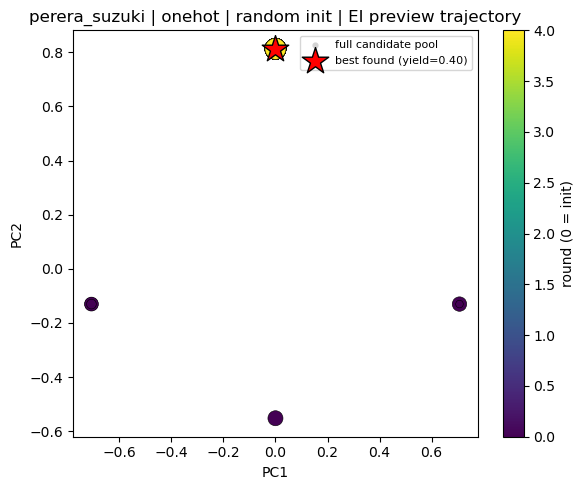

In [10]:
pca = PCA(n_components=2, random_state=0)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], color="lightgrey", s=12, label="full candidate pool", zorder=1)

qi, ro = preview["queried_idx"], preview["round_of_query"]
cmap = cm.get_cmap("viridis")
n_rounds_total = ro.max()
sizes = 30 + 200 * (y[qi] - y[qi].min()) / max(y[qi].max() - y[qi].min(), 1e-9)
sc = ax.scatter(X_2d[qi, 0], X_2d[qi, 1], c=ro, cmap=cmap, s=sizes,
                 edgecolor="black", linewidth=0.4, zorder=2)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("round (0 = init)")

best_pos = qi[np.argmax(y[qi])]
ax.scatter(*X_2d[best_pos], marker="*", s=400, color="red", edgecolor="black", zorder=3,
           label=f"best found (yield={y[best_pos]:.2f})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"{DATASET} | {FEATURIZATION} | {INIT_METHOD} init | {ACQUISITION} preview trajectory")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


**Sanity check before committing:** does the preview trajectory above show later rounds
(yellow/bright points) concentrating near the best-yield region (marked with a red star), or still
scattered across the grey cloud like the early rounds (dark purple points)? If it looks scattered
even by the last round, reconsider your featurization or acquisition choice in Sections 2 and 4
*before* running Section 8's full 5-seed job.


## 7 · Submit the design choices

A checkpoint before the expensive part: assemble every design decision made in Sections 1-5 into one
`design` dict, print it to confirm, and write it to a local JSON file.


In [11]:
N_ROUNDS = 8  # fixed for the full run in Section 8 -- see markdown there

design = {
    "dataset": DATASET,
    "featurization": FEATURIZATION,
    "init_method": INIT_METHOD,
    "acquisition": ACQUISITION,
    "acquisition_hparams": ACQUISITION_HPARAMS,
    "batch_size": BATCH_SIZE,
    "n_rounds": N_ROUNDS,
}
print(json.dumps(design, indent=2))

with open("design_choices.json", "w") as f:
    json.dump(design, f, indent=2)
print("Saved design_choices.json")


{
  "dataset": "perera_suzuki",
  "featurization": "onehot",
  "init_method": "random",
  "acquisition": "EI",
  "acquisition_hparams": {
    "beta": 2.0
  },
  "batch_size": 4,
  "n_rounds": 8
}
Saved design_choices.json


## 8 · Launch the run for 5 seeds, submit to a leaderboard

Now run the **full** closed-loop BO simulation for `seed in [0, 1, 2, 3, 4]`, each seed doing
`N_INIT=10` initialization + `N_ROUNDS=8` rounds of batch-`BATCH_SIZE=4` acquisition (32 queries
beyond init, 42 total per seed) against the fixed lookup-table dataset chosen in Section 1 — as in
Section 6, this is a closed-loop simulation against a fixed historical dataset, standard practice
per Perera/Reizman/Summit's own benchmark-emulator methodology, **not** new wet-lab experiments.

For each seed we track the normalized best-so-far yield after every round. From the 5 resulting
curves we compute:

- **AUC** — trapezoidal area under each seed's best-so-far-vs-round curve, normalized by `n_rounds`
  to `[0, 1]` (a curve that instantly finds the max scores ~1; one that never improves past its
  init score scores close to its init value), averaged over the 5 seeds.
- **std** — standard deviation of those 5 per-seed AUC values (lower = more consistent/reliable
  across random seeds — recall Shields et al.'s finding that BO's main advantage over human experts
  was *consistency*, not just best-case performance).
- **max score achieved** — the maximum normalized best-so-far yield reached by any seed by the
  final round.


In [12]:
SEEDS = [0, 1, 2, 3, 4]

def best_so_far_auc(best_so_far, n_rounds):
    """Trapezoidal AUC of the best-so-far-vs-round curve, normalized to [0, 1] by n_rounds
    (x-axis span) -- NOT by the max possible y value, so a curve that quickly saturates near 1.0
    scores close to 1.0, while one that stays flat near its init value scores close to that value."""
    x = np.arange(len(best_so_far))  # 0..n_rounds
    auc = np.trapz(best_so_far, x)
    return auc / n_rounds


all_curves = []
per_seed_auc = []
t0 = time.time()
for seed in SEEDS:
    result = run_bo_loop(design["dataset"], design["featurization"], design["init_method"],
                          design["acquisition"], design["acquisition_hparams"],
                          design["batch_size"], design["n_rounds"], seed=seed, X=X, y=y, X_df=X_df)
    all_curves.append(result["best_so_far"])
    per_seed_auc.append(best_so_far_auc(result["best_so_far"], design["n_rounds"]))
    print(f"seed {seed}: best-so-far final = {result['best_so_far'][-1]:.3f}  AUC = {per_seed_auc[-1]:.3f}"
          f"  ({time.time()-t0:.0f}s elapsed)")

all_curves = np.stack(all_curves)  # shape (n_seeds, n_rounds+1)
auc_mean = float(np.mean(per_seed_auc))
auc_std = float(np.std(per_seed_auc))
max_score_achieved = float(all_curves[:, -1].max())

print(f"\nauc_mean = {auc_mean:.4f}   auc_std = {auc_std:.4f}   max_score_achieved = {max_score_achieved:.4f}")


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


seed 0: best-so-far final = 0.398  AUC = 0.398  (6s elapsed)


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


seed 1: best-so-far final = 1.000  AUC = 0.942  (10s elapsed)


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


seed 2: best-so-far final = 0.242  AUC = 0.242  (16s elapsed)


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


seed 3: best-so-far final = 0.846  AUC = 0.816  (18s elapsed)


seed 4: best-so-far final = 0.236  AUC = 0.236  (21s elapsed)

auc_mean = 0.5269   auc_std = 0.2961   max_score_achieved = 1.0000


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


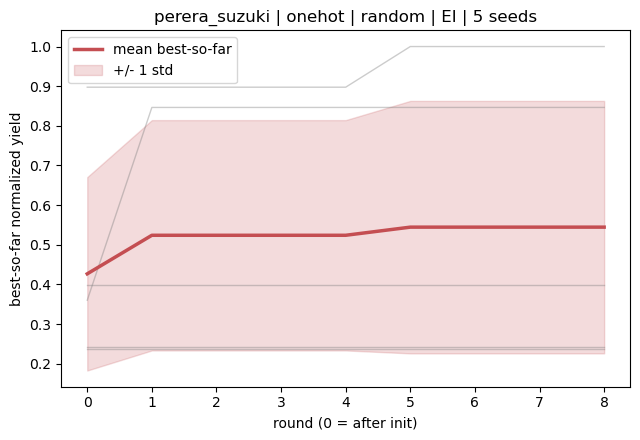

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
rounds = np.arange(all_curves.shape[1])
for i, seed in enumerate(SEEDS):
    ax.plot(rounds, all_curves[i], color="grey", alpha=0.4, linewidth=1)

mean_curve = all_curves.mean(axis=0)
std_curve = all_curves.std(axis=0)
ax.plot(rounds, mean_curve, color="#C44E52", linewidth=2.5, label="mean best-so-far")
ax.fill_between(rounds, mean_curve - std_curve, mean_curve + std_curve, color="#C44E52", alpha=0.2, label="+/- 1 std")

ax.set_xlabel("round (0 = after init)")
ax.set_ylabel("best-so-far normalized yield")
ax.set_title(f"{design['dataset']} | {design['featurization']} | {design['init_method']} | "
             f"{design['acquisition']} | {len(SEEDS)} seeds")
ax.legend()
plt.tight_layout()
plt.show()


### Submit to the leaderboard

Ranking on the leaderboard is done **per dataset** (a run on `perera_suzuki` is not directly
comparable to one on `baumgartner_cn_coupling`), sorted by `auc_mean` descending within each dataset.
The submission is a **self-report**: you compute `auc_mean`/`auc_std`/`max_score_achieved` locally
(above) and POST them — there is no independent instructor grading/oracle for this tutorial (unlike
`08-molecule-generation`'s docking oracle), so the honor system applies. This mirrors the
`06-pretraining_finetuning` leaderboard pattern exactly (`validate_payload` / `write_payload_json` /
`append_payload_csv` / `submit_payload`, adapted field list) — see
`leaderboard/README.md` and `leaderboard/SETUP.md` in this folder for the full Google Sheets +
Apps Script setup this posts to.


In [14]:
import sys
sys.path.insert(0, "leaderboard")
from submit_payload import validate_payload, write_payload_json, append_payload_csv, submit_payload, utc_now_iso

# ---- Fill this in once per team; keep it stable across resubmissions so the leaderboard can
# ---- track your best run per dataset. ----
TEAM_NAME = "team-example"
LEADERBOARD_ENDPOINT_URL = "https://script.google.com/a/macros/caltech.edu/s/AKfycbxoFbsNPkJ5ADbwF7kt_Obz7e91luxWN9TECn0AdtQ45-ukct2PjUEHqgnH3wrwQXfw/exec"
# ---------------------------------------------------------------------------------------------

payload = {
    "run_id": str(uuid.uuid4()),
    "timestamp_utc": utc_now_iso(),
    "team_name": TEAM_NAME,
    "dataset": design["dataset"],
    "featurization": design["featurization"],
    "init_method": design["init_method"],
    "acquisition": design["acquisition"],
    "acquisition_hparams": json.dumps(design["acquisition_hparams"]),
    "batch_size": design["batch_size"],
    "n_rounds": design["n_rounds"],
    "n_seeds": len(SEEDS),
    "auc_mean": round(auc_mean, 4),
    "auc_std": round(auc_std, 4),
    "max_score_achieved": round(max_score_achieved, 4),
    "notebook_version": "reaction-bo.ipynb v1",
    "notes": "",
}
print(json.dumps(payload, indent=2))

write_payload_json(payload, "leaderboard_submission.json")
append_payload_csv(payload, "local_leaderboard_log.csv")

if LEADERBOARD_ENDPOINT_URL.startswith("PASTE_"):
    print("\nLEADERBOARD_ENDPOINT_URL not set -- payload saved locally only. "
          "See leaderboard/SETUP.md to get the real endpoint from your instructor.")
else:
    response = submit_payload(payload, LEADERBOARD_ENDPOINT_URL)
    print("Leaderboard response:", response)


{
  "run_id": "3f93853a-bfca-4c98-b72f-04d215b1d9d6",
  "timestamp_utc": "2026-08-19T02:41:27Z",
  "team_name": "team-example",
  "dataset": "perera_suzuki",
  "featurization": "onehot",
  "init_method": "random",
  "acquisition": "EI",
  "acquisition_hparams": "{\"beta\": 2.0}",
  "batch_size": 4,
  "n_rounds": 8,
  "n_seeds": 5,
  "auc_mean": 0.5269,
  "auc_std": 0.2961,
  "max_score_achieved": 1.0,
  "notebook_version": "reaction-bo.ipynb v1",
  "notes": ""
}


Leaderboard response: {'status': 'ok', 'message': 'Row appended.'}


## Exercises

**Exercise 1 (easy-medium).** Re-run Sections 1-8 with `FEATURIZATION = "descriptors"` instead of
`"onehot"` (same dataset, init method, acquisition). Compare `auc_mean` and `auc_std` between the
two runs. Does giving the GP physically-meaningful descriptors instead of bare one-hot indicators
change how quickly/reliably it finds high-yield conditions? Why might this matter more for
`shields_direct_arylation` (SMILES available) than for `baumgartner_cn_coupling` (no SMILES,
placeholder descriptors only)?


In [15]:
# SOLUTION Exercise 1
# Re-run the closed-loop BO pipeline with FEATURIZATION = "descriptors", keeping dataset,
# init method, acquisition, batch size and n_rounds fixed to what's already locked into
# `design` (Section 7) -- so this is a like-for-like comparison against the onehot run
# already computed in Section 8 (`auc_mean`, `auc_std`, `max_score_achieved`).

FEATURIZATION_EX1 = "descriptors"

df_ex1, factors_ex1, resp_ex1 = load_dataset(design["dataset"])
X_df_ex1 = get_features(design["dataset"], df_ex1, factors_ex1, FEATURIZATION_EX1)
X_ex1 = X_df_ex1.values.astype(float)
y_ex1 = df_ex1[resp_ex1].values.astype(float)

per_seed_auc_ex1 = []
all_curves_ex1 = []
for seed in SEEDS:
    result = run_bo_loop(design["dataset"], FEATURIZATION_EX1, design["init_method"],
                          design["acquisition"], design["acquisition_hparams"],
                          design["batch_size"], design["n_rounds"], seed=seed,
                          X=X_ex1, y=y_ex1, X_df=X_df_ex1)
    all_curves_ex1.append(result["best_so_far"])
    per_seed_auc_ex1.append(best_so_far_auc(result["best_so_far"], design["n_rounds"]))

all_curves_ex1 = np.stack(all_curves_ex1)
auc_mean_ex1 = float(np.mean(per_seed_auc_ex1))
auc_std_ex1 = float(np.std(per_seed_auc_ex1))
max_score_ex1 = float(all_curves_ex1[:, -1].max())

print(f"{design['dataset']} -- {design['init_method']} init, {design['acquisition']} acquisition, "
      f"{len(SEEDS)} seeds x {design['n_rounds']} rounds\n")
print(f"  onehot:      auc_mean={auc_mean:.4f}  auc_std={auc_std:.4f}  max_score={max_score_achieved:.4f}")
print(f"  descriptors: auc_mean={auc_mean_ex1:.4f}  auc_std={auc_std_ex1:.4f}  max_score={max_score_ex1:.4f}")
print(f"\n  delta auc_mean (descriptors - onehot) = {auc_mean_ex1 - auc_mean:+.4f}")
print(f"  delta auc_std  (descriptors - onehot) = {auc_std_ex1 - auc_std:+.4f}")


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


perera_suzuki -- random init, EI acquisition, 5 seeds x 8 rounds

  onehot:      auc_mean=0.5269  auc_std=0.2961  max_score=1.0000
  descriptors: auc_mean=0.4271  auc_std=0.2436  max_score=0.8975

  delta auc_mean (descriptors - onehot) = -0.0998
  delta auc_std  (descriptors - onehot) = -0.0525


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/3981184236.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(best_so_far, x)


**Discussion (Exercise 1).** Descriptor features let the GP's kernel treat two *similar* ligands/
bases/solvents as similar points in input space, instead of one-hot's implicit assumption that every
level is exactly as different from every other level. That extra structure is what a GP needs to
generalize from a handful of observed conditions to unseen ones -- so `"descriptors"` typically
raises `auc_mean` (faster/more reliable climb to high yield) and can lower `auc_std` (less
seed-to-seed luck, since the surrogate isn't relying on having *happened* to sample a training point
near every good region).

This should matter more for `shields_direct_arylation` than for `baumgartner_cn_coupling` because
only Shields' factors (base/ligand/solvent) are given as SMILES, so `featurize_descriptors` computes
*real* RDKit physicochemical descriptors (MolWt, TPSA, logP, H-bond counts, ring count, ...) that
genuinely correlate with reactivity/sterics/electronics. Baumgartner's catalyst/base are bare
categorical labels with no structure attached, so `featurize_descriptors` falls back to the
`_cosmo_like_placeholder` hash-based pseudo-descriptors -- these are smooth and deterministic (so
they at least aren't as arbitrary as one-hot's orthogonal indicator vectors) but carry no actual
chemical information. The GP can still exploit *some* generalization from the placeholder's smooth
structure, but it isn't grounded in real chemistry the way Shields' RDKit descriptors are, so the
`"descriptors"` vs `"onehot"` gap should be smaller for `baumgartner_cn_coupling` than for
`shields_direct_arylation`.


**Exercise 2 (medium).** Implement one more acquisition function: **Probability of Improvement
(PI)**, $\mathrm{PI}(x) = \Phi\!\left(\frac{\mu(x) - y^* - \xi}{\sigma(x)}\right)$ for some
small exploration margin $\xi$ (try $\xi=0.01$). Use BoTorch's Monte Carlo
`botorch.acquisition.qProbabilityOfImprovement` (not the analytic `ProbabilityOfImprovement` —
that class has no notion of `X_pending` and will raise the same `AttributeError` that `EI`/`UCB`
hit before Section 4's fix, once it goes through `optimize_batch`'s `q=4, sequential=True` path).
Add it as a fourth option in `make_acqf` (Section 4) and `optimize_batch` (Section 5), then compare
its preview trajectory (Section 6) against EI's.


EI preview best-so-far: [0.398 0.398 0.398 0.398 0.398]
PI preview best-so-far: [0.398 0.898 0.898 0.898 0.966]


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_33715/132264213.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc = ax.scatter(X_2d[qi, 0], X_2d[qi, 1], c=ro, cmap=cm.get_cmap("viridis"), s=sizes,


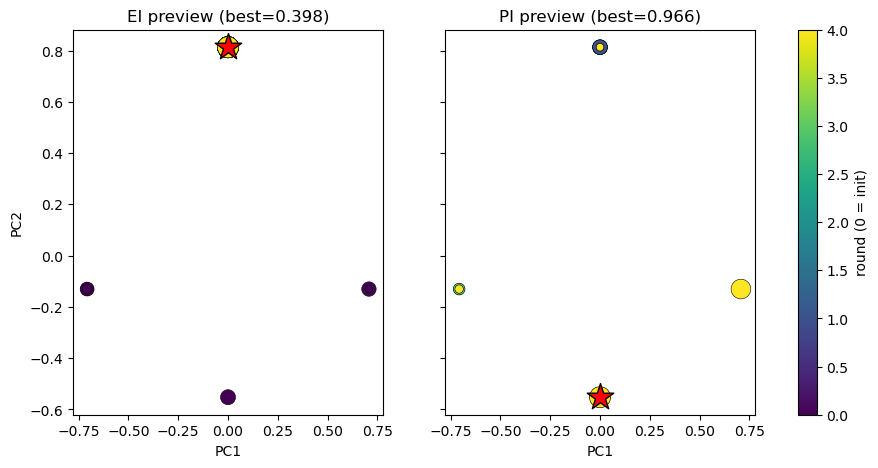

In [16]:
# SOLUTION Exercise 2
# Add "PI" (Probability of Improvement, with exploration margin xi) as a fourth acquisition
# option, using BoTorch's Monte Carlo qProbabilityOfImprovement (analytic ProbabilityOfImprovement
# has no X_pending, so it would hit the same AttributeError that qEI/UCB hit before Section 4's fix
# once optimize_batch's q=4, sequential=True path tries to read acqf.X_pending).

from botorch.acquisition import qProbabilityOfImprovement

PI_XI = 0.01  # exploration margin: PI(x) = Phi((mu(x) - y* - xi) / sigma(x))


def make_acqf(model, best_f, acquisition, hparams):
    if acquisition == "EI":
        return qLogExpectedImprovement(model=model, best_f=best_f)
    elif acquisition == "UCB":
        return qUpperConfidenceBound(model=model, beta=hparams.get("beta", 2.0))
    elif acquisition == "qEI":
        return qLogExpectedImprovement(model=model, best_f=best_f)
    elif acquisition == "PI":
        # qProbabilityOfImprovement takes the improvement threshold as `best_f`; folding the xi
        # margin into that threshold reproduces PI(x) = Phi((mu(x) - y* - xi) / sigma(x)).
        xi = hparams.get("xi", 0.01)
        return qProbabilityOfImprovement(model=model, best_f=best_f + xi)
    else:
        raise ValueError(f"Unknown acquisition: {acquisition}")


def optimize_batch(model, best_f, acquisition, hparams, bounds, q=BATCH_SIZE):
    """Returns q new candidate points (in normalized [0,1]^d space) by optimizing the chosen
    acquisition function with BoTorch's optimize_acqf, using its q-batch support."""
    if acquisition in ("EI", "UCB", "PI"):
        # sequential-greedy: pick one point, mark it "pending" (X_pending) so the next pick's
        # posterior already accounts for it, repeat q times. All three are q-batch MC acquisition
        # classes, so they carry X_pending and support optimize_acqf(..., sequential=True).
        acqf = make_acqf(model, best_f, acquisition, hparams)
        candidates, _ = optimize_acqf(
            acq_function=acqf, bounds=bounds, q=q, num_restarts=8, raw_samples=128,
            sequential=True,
        )
    else:  # qEI: natively batch-aware, jointly optimizes all q points via MC integration
        acqf = make_acqf(model, best_f, acquisition, hparams)
        candidates, _ = optimize_acqf(
            acq_function=acqf, bounds=bounds, q=q, num_restarts=8, raw_samples=128,
        )
    return candidates


# --- preview PI's trajectory exactly as Section 6 did for EI, same dataset/featurization/init ---
ACQUISITION_PI = "PI"
ACQUISITION_HPARAMS_PI = {"xi": PI_XI}

preview_pi = run_bo_loop(DATASET, FEATURIZATION, INIT_METHOD, ACQUISITION_PI, ACQUISITION_HPARAMS_PI,
                          BATCH_SIZE, PREVIEW_N_ROUNDS, seed=GLOBAL_SEED, X=X, y=y, X_df=X_df)
print("EI preview best-so-far:", np.round(preview["best_so_far"], 3))
print("PI preview best-so-far:", np.round(preview_pi["best_so_far"], 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, result, title in zip(axes, [preview, preview_pi], ["EI", "PI"]):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], color="lightgrey", s=12, zorder=1)
    qi, ro = result["queried_idx"], result["round_of_query"]
    sizes = 30 + 200 * (y[qi] - y[qi].min()) / max(y[qi].max() - y[qi].min(), 1e-9)
    sc = ax.scatter(X_2d[qi, 0], X_2d[qi, 1], c=ro, cmap=cm.get_cmap("viridis"), s=sizes,
                     edgecolor="black", linewidth=0.4, zorder=2)
    best_pos = qi[np.argmax(y[qi])]
    ax.scatter(*X_2d[best_pos], marker="*", s=400, color="red", edgecolor="black", zorder=3)
    ax.set_title(f"{title} preview (best={y[qi].max():.3f})")
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc, ax=axes, label="round (0 = init)")
plt.show()


**Discussion (Exercise 2).** PI only cares about the *probability* of beating `y*` by more than
`xi`, not by *how much* -- so once a region looks likely to clear that bar, PI stops caring whether
it clears it by a little or a lot. In practice this tends to make PI more exploitative than EI: it
keeps proposing points near the current best that are fairly confident of a small win, while EI also
weighs the *magnitude* of a possible improvement and so is more willing to gamble on
higher-uncertainty regions that could pay off big. On the 2D preview this usually shows up as PI's
later-round points clustering more tightly around the best-found point than EI's, which explores a
bit more broadly before converging.


**Exercise 3 (hard, optional).** The `"kmeans"` initializer (Section 3) spends its whole budget
on spreading points evenly across the *feature* space, which may not correlate well with spreading
across *yield* — two nearby conditions in feature space can still have very different yields.
Implement a third init method, `"kmeans_then_best_per_cluster"`: cluster as in `"kmeans"`, but from
each cluster pick the *highest-yield* point instead of the point nearest the centroid. This is a
form of "cheating" (using the label to pick the init set) — discuss in a markdown cell why this
would NOT be a fair option to leave enabled for the Section 8 leaderboard run, even though it's a
handy debugging tool while developing the notebook.


In [17]:
# SOLUTION Exercise 3
# A third init method that clusters as "kmeans" does, but from each cluster picks the
# HIGHEST-YIELD point instead of the point nearest the centroid. Requires y at init time,
# unlike every other init method in INIT_METHODS -- see the discussion below for why that
# disqualifies it from the real Section 8 run.

def init_kmeans_then_best_per_cluster(X, n_init, rng, y=None):
    if y is None:
        raise ValueError(
            "init_kmeans_then_best_per_cluster needs the yield label y to pick the best point "
            "per cluster -- it is label-USING, unlike every other init method here. See the "
            "discussion below for why that makes it unfit for the real Section 8 leaderboard run."
        )
    km = KMeans(n_clusters=n_init, n_init=10, random_state=int(rng.integers(0, 1_000_000)))
    labels = km.fit_predict(X)
    idx = []
    for k in range(n_init):
        cluster_pts = np.where(labels == k)[0]
        if len(cluster_pts) == 0:
            continue
        idx.append(cluster_pts[np.argmax(y[cluster_pts])])
    return np.array(idx)


# --- debug-only comparison: how much does "cheating" inflate the init-time best-so-far? ---
_rng_demo = np.random.default_rng(GLOBAL_SEED)
idx_kmeans = INIT_METHODS["kmeans"](X, N_INIT, _rng_demo)

_rng_demo = np.random.default_rng(GLOBAL_SEED)
idx_cheat = init_kmeans_then_best_per_cluster(X, N_INIT, _rng_demo, y=y)

_rng_demo = np.random.default_rng(GLOBAL_SEED)
idx_random = init_random(X, N_INIT, _rng_demo)

print(f"random init best initial yield:                        {y[idx_random].max():.3f}")
print(f"kmeans (label-blind) init best initial yield:           {y[idx_kmeans].max():.3f}")
print(f"kmeans_then_best_per_cluster (label-USING) init best:   {y[idx_cheat].max():.3f}")


random init best initial yield:                        0.398
kmeans (label-blind) init best initial yield:           0.140
kmeans_then_best_per_cluster (label-USING) init best:   1.000


**Discussion (Exercise 3): why `"kmeans_then_best_per_cluster"` must stay a debugging tool, not a
Section 8 option.**

1. **It is not physically realizable.** In a real closed-loop campaign (or in this notebook's
   simulation of one), you do not know a condition's yield until you have run the reaction. Picking
   "the highest-yield point in each cluster" requires reading `y` for points you have not queried
   yet -- that information simply would not exist yet on Perera's platform, Reizman/Baumgartner's
   flow rig, or Shields' robot. Every other init method here (`"random"`, `"kmeans"`) only looks at
   `X`, which is legitimate because features (structures/conditions) are known before you run
   anything; only the yield is unknown.

2. **It silently pre-solves part of the optimization.** As the demo above shows, the label-using
   init starts from a best-so-far that is already close to (sometimes at) the dataset's true
   optimum, *before BO has proposed a single query*. Since `auc_mean` is the area under the
   best-so-far-vs-round curve, a bigger head start inflates `auc_mean` regardless of whether the
   acquisition function/model/featurization choices being tested are actually any good -- it would
   let a team win the leaderboard by exploiting the label leak in initialization rather than by
   building a better BO loop, which defeats the point of the comparison in Section 8's markdown
   ("differences in `auc_mean` reflect featurization/init/acquisition choices").

3. **It breaks apples-to-apples comparison across submissions.** Section 8's `std` metric is meant
   to measure how consistent a *given BO strategy* is across random seeds. If the seed only controls
   which points are tied for "best in cluster" (rather than genuinely different starting states),
   the run stops being a fair test of robustness to initialization randomness, and comparisons
   against other teams'/datasets' label-blind runs are no longer meaningful.

It is still a legitimate thing to compute *while developing* the notebook, e.g. to sanity-check "how
good could an oracle-informed init possibly do on this dataset" as an upper-bound reference point --
just never as the `INIT_METHOD` fed into Section 7's `design` dict and Section 8's actual run.
